In [1]:
import warnings 
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta, date
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
import math

In [2]:
#Lectura de los datos en bruto y eliminación de espacios
metadata=pd.read_csv("../Datos en bruto/Meteorologicos/Humedad/stations.txt",skiprows=17,sep=",")
metadata.columns=metadata.columns.str.strip()
metadata.CN=metadata.CN.str.strip()
metadata.STANAME=metadata.STANAME.str.strip()
metadata

,STAID,STANAME,CN,LAT,LON,HGHT
0,5,LINKOEPING-MALMSLAETT,SE,+58:24:00,+015:31:59,93
1,7,KARLSTAD-AIRPORT,SE,+59:26:40,+013:20:15,107
2,11,KREMSMUENSTER (TAWES),AT,+48:03:18,+014:07:51,382
3,12,GRAZ-UNIVERSITAET,AT,+47:04:40,+015:26:56,367
4,13,INNSBRUCK-UNIV,AT,+47:15:36,+011:23:03,578
...,...,...,...,...,...,...
5963,27942,BOHEMANNESET,SJ,+78:22:54,+014:45:10,8
5964,27943,TOLGA,NO,+62:24:29,+010:59:43,534
5965,27944,E6 STORVIKEIDET,NO,+69:58:14,+023:06:29,73
5966,27945,E6 STOEDI BRU,NO,+66:34:40,+015:21:02,690


In [3]:
#Filtrado de datos para España
metadata_ESP=metadata[metadata.CN=='ES']
metadata_ESP

,STAID,STANAME,CN,LAT,LON,HGHT
128,229,BADAJOZ AEROPUERTO,ES,+38:52:59,-006:48:50,186
130,231,MALAGA AEROPUERTO,ES,+36:39:57,-004:28:55,7
131,232,PUERTO DE NAVACERRADA,ES,+40:47:35,-004:00:38,1893
132,233,SALAMANCA AEROPUERTO,ES,+40:57:33,-005:29:53,790
134,236,ESTACION DE TORTOSA (ROQUETES),ES,+40:49:13,+000:29:35,50
...,...,...,...,...,...,...
5809,27679,MIRANDA DE EBRO,ES,+42:24:41,+002:34:24,460
5810,27683,VALDEZCARAY,ES,+42:09:06,+002:34:49,1630
5811,27684,MEDINA DE POMAR,ES,+42:33:03,+003:17:08,580
5814,27696,BRIVIESCA,ES,+42:19:59,+003:10:59,730


In [4]:
#Funcion para transformación de longitudes y latitudes a formato decimal
def dms_a_decimal(dms_str):
    # Quitar el signo y dividir en partes
    signo = -1 if dms_str.startswith("-") else 1
    partes = dms_str.lstrip("+-").split(":")
    grados, minutos, segundos = map(float, partes)
    decimal = signo * (grados + minutos / 60 + segundos / 3600)
    return decimal

In [5]:
#Transformación de las variables
metadata_ESP['LAT'] = metadata_ESP['LAT'].apply(dms_a_decimal)
metadata_ESP['LON'] = metadata_ESP['LON'].apply(dms_a_decimal)
metadata_ESP

,STAID,STANAME,CN,LAT,LON,HGHT
128,229,BADAJOZ AEROPUERTO,ES,38.883056,-6.813889,186
130,231,MALAGA AEROPUERTO,ES,36.665833,-4.481944,7
131,232,PUERTO DE NAVACERRADA,ES,40.793056,-4.010556,1893
132,233,SALAMANCA AEROPUERTO,ES,40.959167,-5.498056,790
134,236,ESTACION DE TORTOSA (ROQUETES),ES,40.820278,0.493056,50
...,...,...,...,...,...,...
5809,27679,MIRANDA DE EBRO,ES,42.411389,2.573333,460
5810,27683,VALDEZCARAY,ES,42.151667,2.580278,1630
5811,27684,MEDINA DE POMAR,ES,42.550833,3.285556,580
5814,27696,BRIVIESCA,ES,42.333056,3.183056,730


In [6]:
#Carga de mapas para obtener mapa de España
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres")) #Carga de países
spain = world[world["name"] == "Spain"] #Mapa de España

In [7]:
#Transformacion de latitudes y longitudes en puntos
estaciones = [Point(xy) for xy in zip(metadata_ESP['LON'], metadata_ESP['LAT'])] 
puntos = gpd.GeoDataFrame(metadata_ESP, geometry=estaciones, crs="EPSG:4326") 

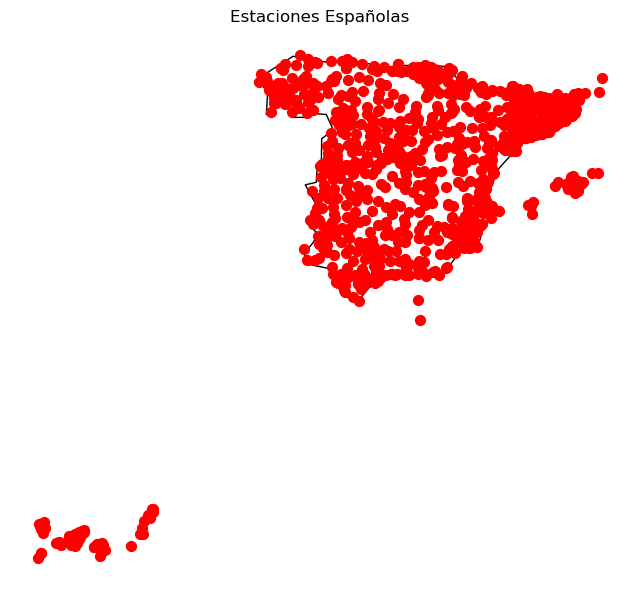

In [8]:
#Gráfica con todas las estaciones
fig, ax = plt.subplots(figsize=(8, 10))
spain.plot(ax=ax, color="white", edgecolor="black")
puntos.plot(ax=ax, color="red", markersize=50)
plt.title("Estaciones Españolas")
plt.axis("off")
plt.show()

In [9]:
#Lista de IDs de estaciones españolas
lista_estaciones_espanolas=metadata_ESP.STAID.to_list()

In [10]:
#Definición del dataframe con información de la primera estación
station='HU_STAID000000'
station_i=station[:-len(str(lista_estaciones_espanolas[0]))]+str(lista_estaciones_espanolas[0])
data=pd.read_csv('../Datos en bruto/Meteorologicos/Humedad/'+str(station_i)+'.txt',skiprows=20,sep=",")
data.columns=data.columns.str.strip()
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2013-01-01') & (data.Q_HU!=9)]
data_unif=data.loc[:,['DATE','HU']]
data_unif.set_index('DATE', inplace=True)
data_unif

,HU
DATE,
2013-01-01,77
2013-01-02,85
2013-01-03,63
2013-01-04,61
2013-01-05,66
...,...
2025-03-25,68
2025-03-26,61
2025-03-27,67


In [11]:
#Anexión de la información del resto de estaciones meteorológicas
for i in lista_estaciones_espanolas[1:]:
    station='HU_STAID000000'
    station_i=station[:-len(str(i))]+str(i)
    data=pd.read_csv('../Datos en bruto/Meteorologicos/Humedad/'+station_i+'.txt',skiprows=20,sep=",")
    data.columns=data.columns.str.strip()
    data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
    data=data[(data.DATE>='2008-01-01') & (data.Q_HU!=9)]
    df=data.loc[:,['DATE','HU']]
    df.set_index('DATE', inplace=True)
    data_unif['HU '+str(i)]=df

data_unif

,HU,HU 231,HU 232,HU 233,HU 236,HU 237,HU 309,HU 336,HU 337,HU 412,...,HU 27656,HU 27665,HU 27667,HU 27670,HU 27672,HU 27679,HU 27683,HU 27684,HU 27696,HU 27700
DATE,,,,,,,,,,,,,,,,,,,,,
2013-01-01,77,74.0,100.0,83.0,62,45,54.0,84.0,91.0,55.0,...,75.0,89.0,90.0,85.0,82.0,77.0,96.0,82.0,85.0,91.0
2013-01-02,85,56.0,100.0,80.0,54,50,50.0,67.0,81.0,55.0,...,89.0,87.0,95.0,85.0,86.0,91.0,100.0,85.0,88.0,99.0
2013-01-03,63,69.0,74.0,81.0,55,49,46.0,64.0,63.0,53.0,...,76.0,77.0,75.0,72.0,68.0,72.0,63.0,69.0,72.0,71.0
2013-01-04,61,78.0,35.0,73.0,52,42,66.0,68.0,70.0,66.0,...,57.0,81.0,75.0,32.0,69.0,80.0,NaN,78.0,74.0,67.0
2013-01-05,66,59.0,42.0,79.0,52,42,37.0,58.0,76.0,43.0,...,67.0,89.0,71.0,56.0,69.0,84.0,40.0,92.0,80.0,69.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-25,68,57.0,100.0,70.0,63,58,68.0,64.0,71.0,63.0,...,87.0,83.0,95.0,85.0,79.0,81.0,100.0,77.0,86.0,NaN
2025-03-26,61,NaN,91.0,69.0,48,56,64.0,66.0,69.0,72.0,...,88.0,83.0,94.0,77.0,79.0,78.0,100.0,77.0,85.0,NaN
2025-03-27,67,51.0,94.0,69.0,53,55,73.0,61.0,67.0,71.0,...,91.0,85.0,95.0,76.0,90.0,81.0,100.0,77.0,90.0,NaN


In [12]:
# Se eliminan todas aquellas estaciones que tienen datos faltantes y se renombra la primera estación con el IDs de estación
d=data_unif.dropna(axis=1)
d=d.rename({'HU':'HU 229'},axis=1)
d

,HU 229,HU 236,HU 237,HU 414,HU 421,HU 3906,HU 3921,HU 3936,HU 3942,HU 3945,...,HU 26990,HU 27034,HU 27045,HU 27046,HU 27232,HU 27422,HU 27423,HU 27450,HU 27610,HU 27631
DATE,,,,,,,,,,,,,,,,,,,,,
2013-01-01,77,62,45,86,63,86,91,86,89,91,...,78,93,78,86,91,73,67,97,84,72
2013-01-02,85,54,50,90,61,65,91,74,92,64,...,65,87,68,81,76,57,62,81,80,73
2013-01-03,63,55,49,77,63,62,79,72,79,62,...,48,85,74,79,67,68,63,77,72,67
2013-01-04,61,52,42,73,69,68,75,88,78,47,...,56,80,76,76,66,73,64,77,62,56
2013-01-05,66,52,42,72,53,63,84,98,93,65,...,59,92,90,97,74,57,75,74,63,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-25,68,63,58,83,59,62,69,84,81,56,...,73,89,86,87,62,65,69,66,75,71
2025-03-26,61,48,56,85,55,59,61,80,72,62,...,70,84,78,77,61,61,64,55,73,65
2025-03-27,67,53,55,85,52,54,65,77,73,65,...,74,89,79,81,64,44,63,59,71,69


In [13]:
# Lista de estaciones españolas sin valores faltantes
v=[]
for i in d.columns:
    v.append(int(i[3:]))
    
mt=metadata_ESP[metadata_ESP.STAID.isin(v)]
mt

,STAID,STANAME,CN,LAT,LON,HGHT
128,229,BADAJOZ AEROPUERTO,ES,38.883056,-6.813889,186
134,236,ESTACION DE TORTOSA (ROQUETES),ES,40.820278,0.493056,50
135,237,VALENCIA,ES,39.480556,-0.366389,11
189,414,BURGOS AEROPUERTO,ES,42.356667,-3.620278,891
196,421,MURCIA,ES,38.001667,-1.170556,62
605,3906,ALBACETE,ES,39.005556,-1.861944,674
620,3921,CACERES,ES,39.471389,-6.338889,394
635,3936,DONOSTIA / SAN SEBASTIAN AEROPUERTO,ES,43.356667,-1.791944,4
640,3942,LLEIDA,ES,41.625833,0.598056,186
643,3945,COLMENAR VIEJO,ES,40.695833,-3.765000,1004


In [14]:
#Transformacion de latitudes y longitudes en puntos
estaciones = [Point(xy) for xy in zip(mt['LON'], mt['LAT'])] 
puntos = gpd.GeoDataFrame(mt, geometry=estaciones, crs="EPSG:4326") 

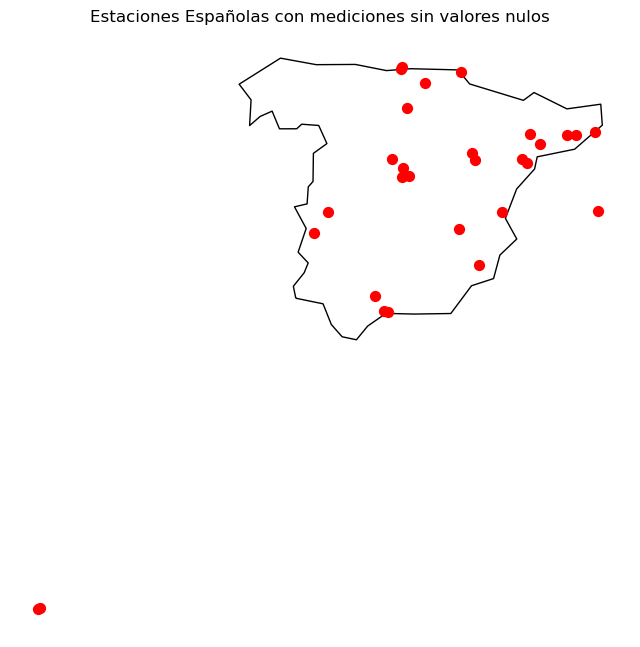

In [15]:
#Gráfica con todas las estaciones
fig, ax = plt.subplots(figsize=(8, 10))
spain.plot(ax=ax, color="white", edgecolor="black")
puntos.plot(ax=ax, color="red", markersize=50)
plt.title("Estaciones Españolas con mediciones sin valores nulos")
plt.axis("off")
plt.show()

In [16]:
#Primer filtrado de estaciones en función del valor truncado de la longitud y latitud
w=[]
ww=[]
for x in zip(mt['LON'],mt['LAT'],mt['STAID']):
    if (math.trunc(x[0]),math.trunc(x[1])) not in w:
        w.append((math.trunc(x[0]),math.trunc(x[1])))
        ww.append(x[2])

mt_esp=mt[mt.STAID.isin(ww)]

In [17]:
#Segundo filtrado de estaciones en función del valor redondeado de la longitud y latitud
w=[]
ww=[]
for x in zip(mt_esp['LON'],mt_esp['LAT'],mt_esp['STAID']):
    if (round(x[0]),round(x[1])) not in w:
        w.append((round(x[0]),round(x[1])))
        ww.append(x[2])
        
mt_ESP=mt_esp[mt_esp.STAID.isin(ww)]
mt_ESP

,STAID,STANAME,CN,LAT,LON,HGHT
128,229,BADAJOZ AEROPUERTO,ES,38.883056,-6.813889,186
134,236,ESTACION DE TORTOSA (ROQUETES),ES,40.820278,0.493056,50
135,237,VALENCIA,ES,39.480556,-0.366389,11
189,414,BURGOS AEROPUERTO,ES,42.356667,-3.620278,891
196,421,MURCIA,ES,38.001667,-1.170556,62
605,3906,ALBACETE,ES,39.005556,-1.861944,674
620,3921,CACERES,ES,39.471389,-6.338889,394
635,3936,DONOSTIA / SAN SEBASTIAN AEROPUERTO,ES,43.356667,-1.791944,4
640,3942,LLEIDA,ES,41.625833,0.598056,186
643,3945,COLMENAR VIEJO,ES,40.695833,-3.765000,1004


In [18]:
#Transformacion de latitudes y longitudes en puntos
estaciones = [Point(xy) for xy in zip(mt_ESP['LON'], mt_ESP['LAT'])] 
puntos = gpd.GeoDataFrame(mt_ESP, geometry=estaciones, crs="EPSG:4326") 

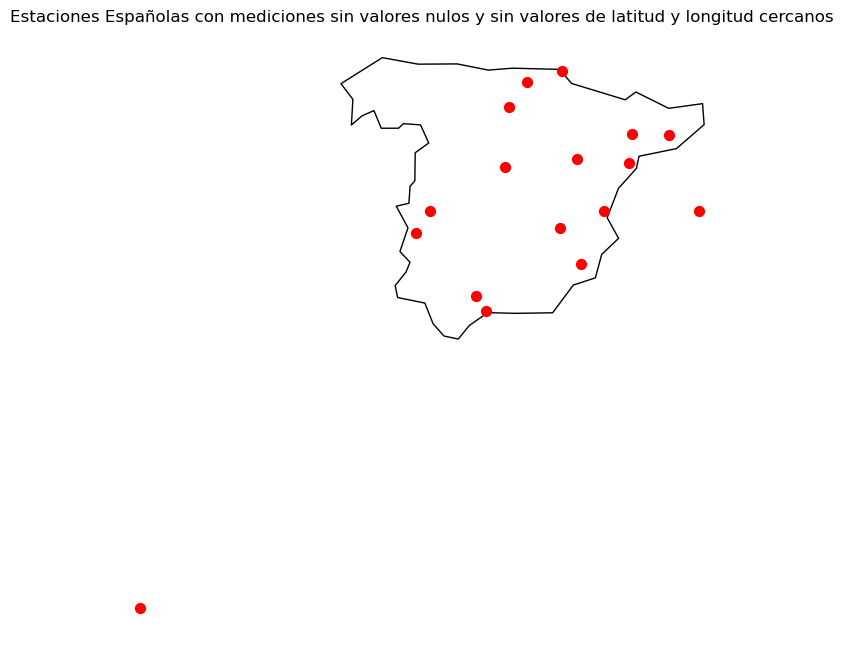

In [19]:
#Gráfica
fig, ax = plt.subplots(figsize=(8, 10))
spain.plot(ax=ax, color="white", edgecolor="black")
puntos.plot(ax=ax, color="red", markersize=50)
plt.title("Estaciones Españolas con mediciones sin valores nulos y sin valores de latitud y longitud cercanos")
plt.axis("off")
plt.show()

In [20]:
#Agrupación de los datos diarios en datos semanales para cada estación
data=d.loc[:,['HU '+str(i) for i in mt_ESP.STAID.to_list()]]
data=data.resample('W').mean()
data

,HU 229,HU 236,HU 237,HU 414,HU 421,HU 3906,HU 3921,HU 3936,HU 3942,HU 3945,HU 3959,HU 3964,HU 26838,HU 26979,HU 27034,HU 27422,HU 27450
DATE,,,,,,,,,,,,,,,,,
2013-01-06,71.833333,53.500000,45.000000,79.166667,58.833333,68.000000,84.666667,84.833333,87.166667,66.333333,63.166667,71.166667,80.000000,55.166667,88.833333,62.833333,81.333333
2013-01-13,72.285714,54.142857,46.428571,91.428571,58.142857,80.142857,90.000000,84.714286,89.714286,92.571429,69.571429,74.142857,79.142857,64.571429,87.000000,55.428571,81.000000
2013-01-20,70.285714,60.285714,45.714286,89.714286,50.857143,74.428571,84.285714,83.857143,71.857143,78.000000,66.000000,75.857143,81.714286,72.285714,88.000000,56.142857,82.428571
2013-01-27,72.571429,54.142857,44.571429,83.285714,47.285714,68.714286,87.714286,75.000000,72.285714,68.857143,59.857143,71.428571,75.000000,64.142857,74.571429,61.142857,85.571429
2013-02-03,62.714286,52.142857,42.142857,87.857143,41.571429,59.428571,80.714286,69.142857,70.571429,71.714286,59.857143,70.285714,72.857143,55.285714,70.714286,51.142857,69.857143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-02,79.285714,69.571429,57.428571,75.714286,68.571429,66.428571,75.285714,67.571429,69.571429,73.714286,62.000000,71.571429,80.428571,72.428571,71.142857,71.142857,70.857143
2025-03-09,84.571429,84.571429,74.714286,85.714286,84.000000,86.857143,83.857143,55.285714,70.857143,93.857143,62.285714,78.714286,89.857143,87.571429,65.857143,79.428571,86.428571
2025-03-16,79.285714,72.571429,56.571429,77.142857,61.857143,70.571429,80.000000,70.571429,76.428571,81.571429,61.000000,75.857143,84.857143,87.571429,81.428571,67.714286,78.428571


In [21]:
#Cálculo de la media para cada semana en función del total de estaciones
a=data.mean(axis=1)
a=pd.DataFrame(a).rename({0:'HU'},axis=1)
a

,HU
DATE,
2013-01-06,70.696078
2013-01-13,74.731092
2013-01-20,72.453782
2013-01-27,68.596639
2013-02-03,64.000000
...,...
2025-03-02,70.747899
2025-03-09,79.672269
2025-03-16,74.319328


In [22]:
#Cálculo de la media para cada semana en función del total de estaciones
a.to_csv('humedad_semanal_esp.csv',index=True,encoding='utf-8')

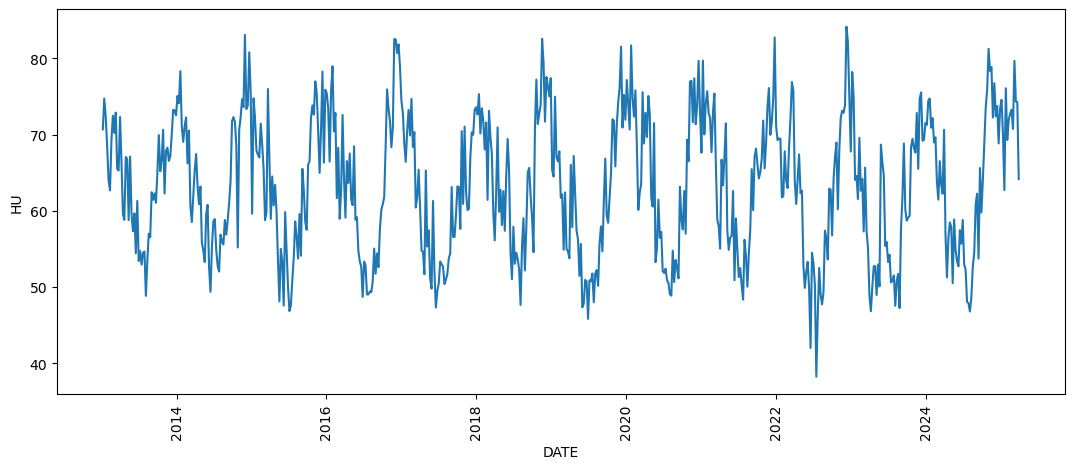

In [23]:
#Visualización de datos mensuales
plt.figure(figsize=(13,5))
sns.lineplot(data=a,x=a.index,y=a.HU)
plt.xticks(rotation=90)
plt.show()